In [1]:
from dataclasses import dataclass
from pathlib import Path
import re

from bisect import bisect_right
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.patches import Rectangle
import numpy as np
from roost import (
    qwen_chat_prompt, 
    CausalModel, 
    EncoderModel,
    InferenceModelResourceManager
)
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm

from server.rangedict import RangeDict
from server.models.coref import CorefModel
from server.manuscript import Manuscript, StoryLines

CLASSIFIER_MODEL = "Qwen/Qwen3.5-4B"
ENCODER_MODEL = "Qwen/Qwen3-Embedding-0.6B"

resource_manager = InferenceModelResourceManager(quota_gb=15)
completion_model = CausalModel(
    CLASSIFIER_MODEL, qwen_chat_prompt, resource_manager, mem_required_gb=5
)
encoder_model = EncoderModel(
    ENCODER_MODEL, resource_manager, mem_required_gb=1
)

SURFACE, GRID, BASELINE, MUTED, INK = "#fcfcfb", "#e1e0d9", "#c3c2b7", "#898781", "#0b0b0b"
ACCENT, REST = "#2a78d6", "#c3c2b7"
WARM, COOL = "#d64a2a", "#2a78d6"
ATTRIBUTION = LinearSegmentedColormap.from_list("attribution", [WARM, SURFACE, COOL])



In [2]:
manuscript = Manuscript.load(Path("./data/story_2.md"))
sections = manuscript.sections
lines = manuscript.lines

## Attribution

In [ ]:

STEPS = 32

def attribution(passage, query, model, tokenizer, steps=STEPS):
    dev = next(model.parameters()).device
    eos = tokenizer.convert_tokens_to_ids("<|endoftext|>")

    def pool(h):
        return F.normalize(h[:, -1], p=2, dim=-1)

    q = tokenizer(f"Instruct: Given a web search query, retrieve relevant "
                  f"passages that answer the query\nQuery:{query}",
                  return_tensors="pt").input_ids.to(dev)
    if q[0, -1] != eos:
        q = torch.cat([q, torch.tensor([[eos]], device=dev)], 1)
    with torch.no_grad():
        qv = pool(model(input_ids=q).last_hidden_state)

    enc = tokenizer(passage, return_tensors="pt", return_offsets_mapping=True)
    ids = enc["input_ids"].to(dev)
    offs = enc["offset_mapping"][0].tolist()
    if ids[0, -1] != eos:
        ids = torch.cat([ids, torch.tensor([[eos]], device=dev)], 1)
        offs.append([0, 0])

    spans = [m.span() for m in re.finditer(r"\S+", passage)]
    words = [passage[s:e] for s, e in spans]
    attrs = [0.0] * len(words)

    wte = model.get_input_embeddings()
    emb = wte(ids).detach()
    neutral = wte.weight.detach().mean(0)
    a = ((torch.arange(steps, device=dev, dtype=emb.dtype) + .5) / steps).view(-1, 1, 1)

    for i, (s, e) in enumerate(offs):
        if e <= s:
            continue
        while s < e and passage[s].isspace():
            s += 1
        w = next((j for j, (ws, we) in enumerate(spans) if ws <= s < we), -1)
        if w < 0:
            continue
        base = emb.clone()
        base[0, i] = neutral
        d = emb - base
        x = (base + a * d).requires_grad_(True)
        sim = (pool(model(inputs_embeds=x).last_hidden_state) * qv).sum()
        g = torch.autograd.grad(sim, x)[0][:, i].mean(0)
        attrs[w] += float((d[0, i] * g).sum())

    return words, attrs

In [ ]:

def plot_attribution(words, totals, query, columns=84, fontsize=11):
    """The passage as it reads, each word shaded by what it contributes."""
    scale = max(map(abs, totals)) or 1.0
    norm = TwoSlopeNorm(vmin=-scale, vcenter=0.0, vmax=scale)

    rows, column = [[]], 0
    for word, total in zip(words, totals):
        if column + len(word) > columns and rows[-1]:
            rows.append([])
            column = 0
        rows[-1].append((word, total, column))
        column += len(word) + 1

    # A monospace glyph advances 0.6 em; the extra buys the margins back.
    inches_per_column = fontsize * 0.72 / 72
    fig, ax = plt.subplots(
        figsize=(columns * inches_per_column, len(rows) * fontsize * 2.1 / 72 + 1.4)
    )
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)
    ax.set_xlim(-0.5, columns + 0.5)
    ax.set_ylim(len(rows), -0.4)
    ax.axis("off")

    for row, entries in enumerate(rows):
        for word, total, column in entries:
            shade = ATTRIBUTION(norm(total))
            ax.add_patch(Rectangle(
                (column - 0.3, row + 0.12), len(word) + 0.6, 0.76,
                facecolor=shade, edgecolor="none",
            ))
            luminance = 0.299 * shade[0] + 0.587 * shade[1] + 0.114 * shade[2]
            ax.text(
                column, row + 0.5, word,
                family="monospace", fontsize=fontsize, va="center", ha="left",
                color=INK if luminance > 0.55 else SURFACE,
            )

    ax.set_title(
        f"“{query}”",
        loc="left", fontsize=10, color=MUTED, pad=14,
    )
    bar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=ATTRIBUTION),
        ax=ax, orientation="horizontal", fraction=0.06, pad=0.04, aspect=50,
    )
    bar.outline.set_visible(False)
    bar.ax.tick_params(colors=MUTED, labelsize=8, length=0)
    bar.set_label("contribution to the alignment", color=MUTED, fontsize=9)
    fig.tight_layout()
    return fig

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

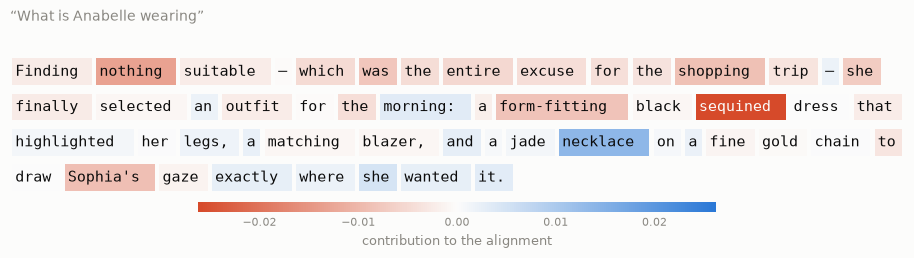

In [ ]:
passage = "Finding nothing suitable — which was the entire excuse for the shopping trip — she finally selected an outfit for the morning: a form-fitting black sequined dress that highlighted her legs, a matching blazer, and a jade necklace on a fine gold chain to draw Sophia's gaze exactly where she wanted it."
query = "What is Anabelle wearing"

model, tokenizer = encoder_model.load()
words, totals = attribution(passage, query, model, tokenizer)
figure = plot_attribution(words, totals, query)

Thoughts - the part that corresponds to the request gets highlit correclty. 
The's because the lione may contain more information is why it's not given a correct score.

The other thing is that information may be divided - the "she" used in one line might be defined in another.


## Nodes

The line is not the node. A node is a thing the story refers to, and lines are the
evidence for it — which is what lets "she" and "Anabelle" be one node when their
encodings are nowhere near each other.

### Coreference resolution
Graph nodes represent entities from the text - unique entities.

So if in our text we have a character, then all references to that character, either named (e.g. Anabelle) or anonymous (e.g. she, her) - have to be identified and attributed to a single node.

The ML task that does that is called "coreference resolution".
An example of a model trained for this type of task is "biu-nlp/lingmess-coref"

In [3]:
@dataclass(frozen=True)
class KnowledgeItem:
    """Represents a single entity from a body of knowledge.
    
    That thing might be a subject - a person, a place, an object; a concept; an event; a situation.
    """

    id: int  # Unique id
    mentions: tuple[tuple[int, int], ...]  # where in text is the item mentioned (start character, end character)



In [4]:
COREF_MODEL = "biu-nlp/lingmess-coref"
COREF_MODEL_GB = 2


def knowledge_items(model: CorefModel, text: str) -> tuple[KnowledgeItem, ...]:
    """Every entity the text refers to, each one carrying the mentions that refer to it."""
    return tuple(
        KnowledgeItem(id=index, mentions=tuple(map(tuple, cluster)))
        for index, cluster in enumerate(model.clusters(text))
    )


coref_model = CorefModel(COREF_MODEL, resource_manager, COREF_MODEL_GB)


In [5]:
STORIES = manuscript.sections[:2]


def story_text(section):
    """A section as the resolver reads it, and as the annotation was written against."""
    return "\n".join(section.lines)


# Both stories sit well inside the model's 4096 tokens, so each is read in one pass and
# the spans that come back are already positioned against the text they were read from.
items_of_story = [
    knowledge_items(coref_model, story_text(section))
    for section in tqdm(STORIES, desc="resolving", unit="story")
]

for section, found in zip(STORIES, items_of_story):
    text = story_text(section)
    print(f"\n{section.title}: {len(found)} items from {len(text.split())} words\n")
    for item in sorted(found, key=lambda item: -len(item.mentions))[:15]:
        written = sorted(
            {text[start:end] for start, end in item.mentions}, key=len, reverse=True
        )
        print(f"  {item.id:>4}{len(item.mentions):>6}  {', '.join(written)[:66]}")

# Out
#   items_of_story  one tuple of KnowledgeItem per story, in that story's own coordinates


resolving:   0%|          | 0/2 [00:00<?, ?story/s]

20:55:22  94848 resource_manager Preparing biu-nlp/lingmess-coref for serving ...
20:55:24  94848 httpx        HTTP Request: HEAD https://huggingface.co/biu-nlp/lingmess-coref/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:55:24  94848 httpx        HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/lingmess-coref/fa5d8a827a09388d03adbe9e800c7d8c509c3935/config.json "HTTP/1.1 200 OK"
20:55:25  94848 httpx        HTTP Request: HEAD https://huggingface.co/biu-nlp/lingmess-coref/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
20:55:25  94848 httpx        HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/biu-nlp/lingmess-coref/fa5d8a827a09388d03adbe9e800c7d8c509c3935/config.json "HTTP/1.1 200 OK"
20:55:25  94848 httpx        HTTP Request: HEAD https://huggingface.co/biu-nlp/lingmess-coref/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
20:55:25  94848 httpx        HTTP Request: HEAD https://huggingface.c

Loading weights: 100%|██████████| 565/565 [00:00<00:00, 79509.54it/s]
[transformers] LingMessModel LOAD REPORT from: biu-nlp/lingmess-coref
Key                                | Status     |  | 
-----------------------------------+------------+--+-
longformer.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


20:55:26  94848 httpx        HTTP Request: GET https://huggingface.co/api/models/biu-nlp/lingmess-coref "HTTP/1.1 200 OK"


Map: 100%|██████████| 1/1 [00:00<00:00, 36.16 examples/s]
/Users/piotrtrochim/GitHub/writer/.venv/lib/python3.12/site-packages/pyarrow/compute.py:230: FutureWarning: Specifying null_placement in SortOptions is deprecated as of 25.0.0. Specify null_placement per sort_key instead.
  return options_class(*args, **kwargs)
Inference:   0%|          | 0/1 [00:00<?, ?it/s]

...

Inference: 100%|██████████| 1/1 [00:01<00:00,  1.33s/it]


20:55:28  94848 fastcoref.modeling Tokenize 1 inputs...


Inference:   0%|          | 0/1 [00:00<?, ?it/s]

20:55:28  94848 fastcoref.modeling ***** Running Inference on 1 texts *****

Preface: 12 items from 253 words

     2     5  a man, his, he, He
     0     4  a different reality, that reality, It, it
     4     3  a woman’s, her
    10     3  One in particular, that rule, it
    11     3  a woman who broke that rule, and the consequences it carried for h
     1     2  a singular choice: freedom or safety, That choice
     3     2  the Matriarchy, the Society
     5     2  The men who surrender to this life, their
     6     2  *Companions*, their
     7     2  This society, it
     8     2  no woman, her
     9     2  a man, He

One: 12 items from 608 words

     0    52  Anabelle, she, her, She, Her
     1    36  Her Companion, her Companion, his, His, him, He, he
     4     3  the delicious pastry, the croissant, the pastry
    10     3  the leather leash, its, it
     2     2  the little bell attached to his caged genitals, it
     3     2  the musical sound, chimed
     5     2  hi

Inference: 100%|██████████| 1/1 [00:01<00:00,  1.19s/it]


Our task is to discover relationships between two entities given the following constraints:
- those two entities appear multiple times in the text
- they may be related by many different relationships
- a single may, but doesn't have to, connect them
- we don't know the names of those relationships.

There doesn't exist a single algorithm that would solve that problem. Here's what I found to exist.

#### OpenRE

OpenRE is the standard for discovering relations between entities when the set of
possible relations is not known in advance. In practice it is done at sentence level:
one sentence, one entity pair, one relation.
The sentence in this case is a real, linguistic sentence, punctuation delimited.

It outputs k unlabeled clusters that encode relations between the entities.

#### ATLOP
Adaptive Thresholding and Localized cOntext Pooling, introduced in [Document-Level Relation Extraction with Adaptive Thresholding and Localized Context Pooling](https://arxiv.org/abs/2010.11304) in 2021.

Tick nearly every box on our list, except form the last one - it requires a fixed list of named relations — its output layer has one logit per relation, and nothing outside that list can be emitted.

#### Schema induction

The state of the art is [AutoSchemaKG](https://arxiv.org/html/2505.23628v1) which uses an LLM (so an LLM decoder).

It's a pipeline (not a model) that involves an intruction-tuned LLM prompted to discover entities and relationships between them. It produces named relationships, that we could certainly benefit from. However - it uses a generative approach, meaning that the model decides WHAT relationships to generate for us - and will return a lot of False Negatives (missing relationships) and False Positives (some named relationships may be mislabeled or outright connect incorrect entities)



## Grading

In [6]:
preface = manuscript.sections[0]
chapter_1 = manuscript.sections[1]
stories = [preface, chapter_1]

@dataclass(frozen=True)
class KnowledgeRelation:
    start: int
    end: int

@dataclass(frozen=True)
class KnowledgeGraph:
    nodes: list[KnowledgeItem]
    edges: list[KnowledgeRelation]

relationships_in_story_1 = KnowledgeGraph(
    nodes=[
        # World
        KnowledgeItem(0, mentions=(
            preface.reference(line=0, phrase="different reality"),
            preface.reference(line=1, phrase="world of abundance, beauty, and peace"),
            preface.reference(line=1, phrase="that reality"),
            preface.reference(line=2, phrase="the outer lands"),
            preface.reference(line=4, phrase="This society"),
        )),
        # Men
        KnowledgeItem(1, mentions=(
            preface.reference(line=1, phrase="For men"),
            preface.reference(line=2, phrase="a man"),
            preface.reference(line=2, phrase="He can walk"),
            preface.reference(line=2, phrase="he can enter"),
            preface.reference(line=2, phrase="he must accept"),
            preface.reference(line=2, phrase="men serve"),
            preface.reference(line=3, phrase="The men who surrender"),
            preface.reference(line=3, phrase="Drones"),
            preface.reference(line=3, phrase="Companions"),
            preface.reference(line=4, phrase="a man"),
            preface.reference(line=4, phrase="a subject"),
        )),
        # Women
        KnowledgeItem(2, mentions=(
            preface.reference(line=1, phrase="the women"),
            preface.reference(line=2, phrase="Women rule"),
            preface.reference(line=3, phrase="her every command"),
            preface.reference(line=3, phrase="bow before her"),
            preface.reference(line=3, phrase="Mistresses"),
            preface.reference(line=4, phrase="the ruling class"),
            preface.reference(line=4, phrase="no woman"),
            preface.reference(line=4, phrase="a partner"),
            preface.reference(line=5, phrase="a woman"),
            preface.reference(line=5, phrase="she"),
        )),
        # Outside the matriarchy
        KnowledgeItem(3, mentions=(
            preface.reference(line=2, phrase="outer lands"),
            preface.reference(line=2, phrase="patriarchal society"),
        )),
        # Matriarchy
        KnowledgeItem(3, mentions=(
            preface.reference(line=1, phrase="world of abundance, beauty, and peace"),
            preface.reference(line=2, phrase="Matriarchy"),
            preface.reference(line=3, phrase="the Society"),
            preface.reference(line=4, phrase="This society"),
        )),
        # Freedom
        KnowledgeItem(4, mentions=(
            preface.reference(line=1, phrase="freedom"),
            preface.reference(line=2, phrase="walk away"),
            preface.reference(line=2, phrase="a life of humble poverty"),
            preface.reference(line=2, phrase="Women rule"),
            preface.reference(line=3, phrase="sovereignty"),
        )),
        # Servitude
        KnowledgeItem(5, mentions=(
            preface.reference(line=1, phrase="safety"),
            preface.reference(line=2, phrase="enter the Matriarchy"),
            preface.reference(line=2, phrase="enveloped in safety"),
            preface.reference(line=2, phrase="men serve"),
            preface.reference(line=3, phrase="Disobedience"),
            preface.reference(line=3, phrase="punishments"),
            preface.reference(line=3, phrase="The men who surrender"),
            preface.reference(line=3, phrase="devotion"),
            preface.reference(line=3, phrase="personal maids"),
            preface.reference(line=3, phrase="bound"),
            preface.reference(line=4, phrase="strict rules that govern it"),
            preface.reference(line=4, phrase="controlling basic male instincts"),
        )),
    ],
    edges=[
        KnowledgeRelation(1, 0),  # Men -> World
        KnowledgeRelation(2, 0),  # Women -> World
        KnowledgeRelation(1, 3),  # Men -> Outside the matriarchy
        KnowledgeRelation(1, 4),  # Men -> Matriarchy
        KnowledgeRelation(2, 4),  # Women -> Matriarchy
        KnowledgeRelation(3, 0),  # Outside the matriarchy -> World
        KnowledgeRelation(4, 0),  # Matriarchy -> World
        KnowledgeRelation(1, 4),  # Men -> Freedom
        KnowledgeRelation(1, 5),  # Men -> Servitude
        KnowledgeRelation(2, 4),  # Women -> Freedom
    ],
)

relationships_in_story_2 = KnowledgeGraph(
    nodes=[
        # Anabelle
        KnowledgeItem(0, mentions=(
            chapter_1.reference(line=0, phrase="Anabelle"),
            chapter_1.reference(line=0, phrase="She stretched"),
            chapter_1.reference(line=1, phrase="Her"),
            chapter_1.reference(line=1, phrase="She"),
            chapter_1.reference(line=1, phrase="her stomach"),
            chapter_1.reference(line=2, phrase="She"),
            chapter_1.reference(line=2, phrase="a single fingertip"),
            chapter_1.reference(line=3, phrase="She bit into"),
            chapter_1.reference(line=4, phrase="she liked"),
            chapter_1.reference(line=4, phrase="her"),
            chapter_1.reference(line=5, phrase="Anabelle"),
            chapter_1.reference(line=5, phrase="She loved"),
            chapter_1.reference(line=5, phrase="she washed"),
            chapter_1.reference(line=6, phrase="she finished"),
            chapter_1.reference(line=6, phrase="she swung her feet"),
            chapter_1.reference(line=6, phrase="her toes"),
            chapter_1.reference(line=6, phrase="She stepped"),
            chapter_1.reference(line=7, phrase="She"),
            chapter_1.reference(line=8, phrase="she twirled"),
            chapter_1.reference(line=8, phrase="her heel"),
            chapter_1.reference(line=8, phrase="She was meeting"),
            chapter_1.reference(line=9, phrase="her legs"),
            chapter_1.reference(line=9, phrase="where she wanted"),
            chapter_1.reference(line=10, phrase="She draped"),
            chapter_1.reference(line=10, phrase="she pressed"),
            chapter_1.reference(line=11, phrase="before her"),
            chapter_1.reference(line=11, phrase="her thighs"),
            chapter_1.reference(line=11, phrase="her face"),
            chapter_1.reference(line=11, phrase="she might have caught"),
            chapter_1.reference(line=11, phrase="she had"),
            chapter_1.reference(line=12, phrase="her feet"),
            chapter_1.reference(line=12, phrase="her instep"),
            chapter_1.reference(line=13, phrase="She checked"),
            chapter_1.reference(line=13, phrase="her reflection"),
        )),
        # Companion
        KnowledgeItem(1, mentions=(
            chapter_1.reference(line=1, phrase="Companion"),
            chapter_1.reference(line=2, phrase="he strained"),
            chapter_1.reference(line=3, phrase="Her Companion"),
            chapter_1.reference(line=4, phrase="keep him"),
            chapter_1.reference(line=4, phrase="a Companion"),
            chapter_1.reference(line=4, phrase="He held"),
            chapter_1.reference(line=4, phrase="he had"),
            chapter_1.reference(line=4, phrase="he first"),
            chapter_1.reference(line=5, phrase="his hip"),
            chapter_1.reference(line=5, phrase="his skin"),
            chapter_1.reference(line=5, phrase="on him"),
            chapter_1.reference(line=6, phrase="her Companion"),
            chapter_1.reference(line=6, phrase="his mouth"),
            chapter_1.reference(line=10, phrase="Her Companion"),
            chapter_1.reference(line=11, phrase="He stretched"),
            chapter_1.reference(line=11, phrase="his stiff arms and knelt"),
            chapter_1.reference(line=11, phrase="his hands"),
            chapter_1.reference(line=11, phrase="His eyes"),
            chapter_1.reference(line=11, phrase="his gaze"),
            chapter_1.reference(line=11, phrase="challenge him"),
            chapter_1.reference(line=12, phrase="Her Companion"),
            chapter_1.reference(line=12, phrase="His arms"),
            chapter_1.reference(line=12, phrase="his wrists"),
        )),
        # Sophia
        KnowledgeItem(2, mentions=(
            chapter_1.reference(line=8, phrase="Sophia"),
            chapter_1.reference(line=9, phrase="Sophia's gaze"),
        )),
        # Anabelle's outfit
        KnowledgeItem(3, mentions=(
            chapter_1.reference(line=6, phrase="her slippers"),
            chapter_1.reference(line=8, phrase="something appropriate"),
            chapter_1.reference(line=8, phrase="something appropriate"),
            chapter_1.reference(line=8, phrase="sexy, yet professional and understated"),
            chapter_1.reference(line=9, phrase="nothing suitable"),
            chapter_1.reference(line=9, phrase="an outfit for the morning"),
            chapter_1.reference(line=9, phrase="form-fitting black sequined dress"),
            chapter_1.reference(line=9, phrase="blazer"),
            chapter_1.reference(line=9, phrase="a jade necklace on a fine gold chain"),
            chapter_1.reference(line=10, phrase="the clothes"),
            chapter_1.reference(line=11, phrase="Panties"),
            chapter_1.reference(line=11, phrase="hosiery"),
            chapter_1.reference(line=11, phrase="skirt"),
            chapter_1.reference(line=11, phrase="dress"),
            chapter_1.reference(line=12, phrase="stilettos"),
        )),
        # Companion's outfit
        KnowledgeItem(4, mentions=(
            chapter_1.reference(line=1, phrase="his chastity belt"),
            chapter_1.reference(line=2, phrase="the little bell attached to his caged genitals"),
            chapter_1.reference(line=4, phrase="The chastity belt"),
            chapter_1.reference(line=4, phrase="he small gauge set into the metal"),
            chapter_1.reference(line=4, phrase="her collar"),
            chapter_1.reference(line=10, phrase="the release button on his collar"),
            chapter_1.reference(line=10, phrase="the armbinder"),
            chapter_1.reference(line=12, phrase="the armbinder"),
            chapter_1.reference(line=13, phrase="leather leash"),
            chapter_1.reference(line=13, phrase="the ring on his collar"),
        )),
        # Bedroom
        KnowledgeItem(5, mentions=(
            chapter_1.reference(line=6, phrase="the edge of the mattress"),
            chapter_1.reference(line=6, phrase="bed"),
            chapter_1.reference(line=6, phrase="the window"),
            chapter_1.reference(line=8, phrase="the wardrobe"),
            chapter_1.reference(line=10, phrase="the bed"),
            chapter_1.reference(line=13, phrase="hook by the door"),
        )),
        # Shopping trip & day plans
        KnowledgeItem(6, mentions=(
            chapter_1.reference(line=7, phrase="a day she had long anticipated"),
            chapter_1.reference(line=7, phrase="an offer from a prestigious law firm"),
            chapter_1.reference(line=8, phrase="reckless shopping spree"),
            chapter_1.reference(line=8, phrase="proper hot date"),
            chapter_1.reference(line=9, phrase="the shopping trip"),
        )),
        # Breakfast
        KnowledgeItem(7, mentions=(
            chapter_1.reference(line=1, phrase="the glass and took a long sip"),
            chapter_1.reference(line=1, phrase="the sweet, silky blend of carrot and apple"),
            chapter_1.reference(line=1, phrase="the crispy, golden-brown crust of the croissant"),
            chapter_1.reference(line=3, phrase="the delicious pastry"),
            chapter_1.reference(line=5, phrase="the pastry"),
            chapter_1.reference(line=5, phrase="solid swig of juice"),
        )),
        # Gestures
        KnowledgeItem(8, mentions=(
            chapter_1.reference(line=3, phrase="a lazy, whirlpool gesture in the air with her other hand"),
            chapter_1.reference(line=10, phrase="flicked her fingers"),
        )),
        # Poses
        KnowledgeItem(9, mentions=(
            chapter_1.reference(line=3, phrase="turning around"),
            chapter_1.reference(line=4, phrase="the pose"),
        )),
        # Routines
        KnowledgeItem(10, mentions=(
            chapter_1.reference(line=4, phrase="his milking"),
            chapter_1.reference(line=11, phrase="a routine trained deep into his muscles"),
            chapter_1.reference(line=12, phrase="planted a reverent kiss on her instep, signaling his task was complete"),
        )),
    ],
    edges=[
        KnowledgeRelation(1, 0),  # Companion -> Anabelle
        KnowledgeRelation(0, 2),  # Anabelle -> Sophia
        KnowledgeRelation(0, 3),  # Anabelle -> Anabelle's outfit
        KnowledgeRelation(1, 3),  # Companion -> Anabelle's outfit
        KnowledgeRelation(0, 4),  # Anabelle -> Companion's outfit
        KnowledgeRelation(1, 4),  # Companion -> Companion's outfit
        KnowledgeRelation(0, 5),  # Anabelle -> Bedroom
        KnowledgeRelation(1, 5),  # Companion -> Bedroom
        KnowledgeRelation(1, 5),  # Companion -> Bedroom
        KnowledgeRelation(0, 6),  # Anabelle -> Shopping trip & day plans
        KnowledgeRelation(0, 7),  # Anabelle -> Breakfast
        KnowledgeRelation(1, 7),  # Companion -> Breakfast
        KnowledgeRelation(0, 8),  # Anabelle -> Gestures
        KnowledgeRelation(8, 1),  # Gestures -> Companion
        KnowledgeRelation(8, 9),  # Gestures -> Poses
        KnowledgeRelation(1, 9),  # Companion -> Poses
        KnowledgeRelation(0, 10),  # Anabelle -> Routines
        KnowledgeRelation(1, 10),  # Companion -> Routines
    ],
)

relationships_in_story_1

KnowledgeGraph(nodes=[KnowledgeItem(id=0, mentions=((32, 48), (8, 44), (113, 124), (75, 89), (0, 11))), KnowledgeItem(id=1, mentions=((104, 110), (35, 39), (55, 65), (191, 202), (290, 303), (335, 343), (237, 257), (304, 309), (346, 355), (282, 286), (305, 313))), KnowledgeItem(id=2, mentions=((81, 89), (323, 332), (123, 139), (146, 159), (401, 410), (182, 197), (259, 266), (322, 330), (21, 27), (103, 105))), KnowledgeItem(id=3, mentions=((79, 89), (131, 149))), KnowledgeItem(id=3, mentions=((8, 44), (208, 217), (10, 20), (0, 11))), KnowledgeItem(id=4, mentions=((159, 165), (62, 70), (101, 124), (323, 332), (51, 61))), KnowledgeItem(id=5, mentions=((170, 175), (198, 217), (220, 238), (335, 343), (179, 190), (214, 224), (237, 257), (293, 300), (370, 383), (386, 390), (55, 81), (113, 144)))], edges=[KnowledgeRelation(start=1, end=0), KnowledgeRelation(start=2, end=0), KnowledgeRelation(start=1, end=3), KnowledgeRelation(start=1, end=4), KnowledgeRelation(start=2, end=4), KnowledgeRelation

In [ ]:
from collections import Counter
from typing import NamedTuple

ANNOTATED = (relationships_in_story_1, relationships_in_story_2)

IntRange = tuple[int, int]


class ClassificationMetrics(NamedTuple):
    accuracy: float
    recall: float
    fpr: float  # false positive rate
    precision: float


def overlaps(lhs: IntRange, rhs: IntRange) -> bool:
    """Whether two half-open ranges hold any character in common."""
    return lhs[0] < rhs[1] and rhs[0] < lhs[1]


def classification_statistics(
    labels: list[KnowledgeItem], actual_values: list[KnowledgeItem]
) -> ClassificationMetrics:
    """How much of an annotated item a single found item accounts for.
    
    Correct Classifications / Total Classifications
    where correct classifications == TP + TN
    """
    n_samples = 0

    # first, flatten all label ranges and identify which unique ranges match which 
    # labelled object clusters
    label_clusters: RangeDict[int] = RangeDict()
    for label in labels:
        for label_range in label.mentions:
            n_samples += 1
            label_clusters[label_range] = label.id

    # next, take the actual values and attempt to match them to those ranges and clusters.
    # Actual value clustering ordering might be completely different, and their ranges
    # may not match precisely. 
    # That is ok.
    # In this pass we are looking for rough, overlaping matches of the ranges - and when we detect
    # one, we record the cluster ids of the matching label and actual value, respectively
    matching_clusters: RangeDict[tuple[int, int]] = RangeDict()
    for value in actual_values:
        value_cluster_id = value.id
        for value_range in value.mentions:
            for label_range, label_cluster_id in label_clusters.items():
                if overlaps(label_range, value_range):
                    matching_clusters[label_range] = (label_cluster_id, value_cluster_id)

    # once that step is complete, we can proceed to inspecting HOW MANY of the label cluster entries 
    # MATCH the actual value cluster.
    # that way, we want to accomplish two things:
    # - find a mapping between label and actual_value cluster numbers (probabilistic mapping)
    # - identify how many of the values were mapped
    #
    # so if a label cluster had 10 entries and an id==5, and after this step we discovered that:
    #  - 4 of its entries map to actual value cluster id == 3
    #  - 2 of its entries map to actual value cluster id == 1
    #  - the rest of the entries are not mapped
    # we will surmise that there's a 40% chance of this being cluster 3, and that will be the accuracy of identifying that cluster
    #
    # A mention speaks once for each found cluster it was matched to, so a label
    # cluster can be no more than wholly accounted for by any one of them.
    true_positives = 0
    true_negatives = 0
    false_positives = 0
    false_negatives = 0
    for label in labels:
        found_in: Counter[int] = Counter()
        for label_range in label.mentions:
            found_in.update(
                {
                    value_cluster_id
                    for label_cluster_id, value_cluster_id in matching_clusters[label_range]
                    if label_cluster_id == label.id
                }
            )
        true_positives += max(found_in.values(), default=0)

    accuracy = (true_positives + true_negatives) / n_samples
    recall = 0.
    fpr = 0.
    precision = 0.
    return ClassificationMetrics(accuracy, recall, fpr, precision)


for section, gold, found in zip(STORIES, ANNOTATED, items_of_story):
    metrics = classification_statistics(gold.nodes, found)
    print(
        f"{section.title:<12} "
        f"accuracy={metrics.accuracy:>4.0%}, "
        f"recall={metrics.recall:>4.0%}, "
        f"false_positive_rate={metrics.fpr:>4.0%}, "
        f"precision={metrics.precision:>4.0%}"
    )

# Out
#   accuracy   of an annotated item's mentions, the share carried by the one found
#              item that accounts for most of them
#   mean       that share averaged over the annotated items
#   std        how far the items spread around it


Preface      accuracy mean= 24%, std= 14%
One          accuracy mean= 55%, std= 18%
